In [1]:
import numpy
import scipy
import matplotlib.pyplot as plt
import matplotlib

#### one die

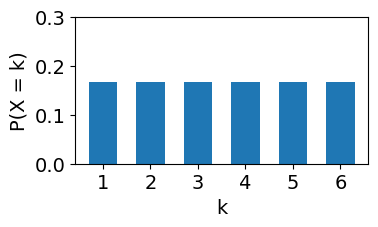

In [2]:
# get probabilities
xs = numpy.arange (1,7)
ys = numpy.full (len(xs), 1/6)

# text size
matplotlib.rcParams["font.size"] = 14

# plot them
(fig, ax) = plt.subplots(figsize=(4,2.5))
ax.bar(xs, ys, width=0.6)
ax.set_ylim ((0,0.3))
ax.set_ylabel ("P(X = k)")
ax.set_xlabel ("k")
ax.set_xticks ([1,2,3,4,5,6])

# save plot
fig.tight_layout()
fig.savefig ("uniform_die.pdf")

#### binomial

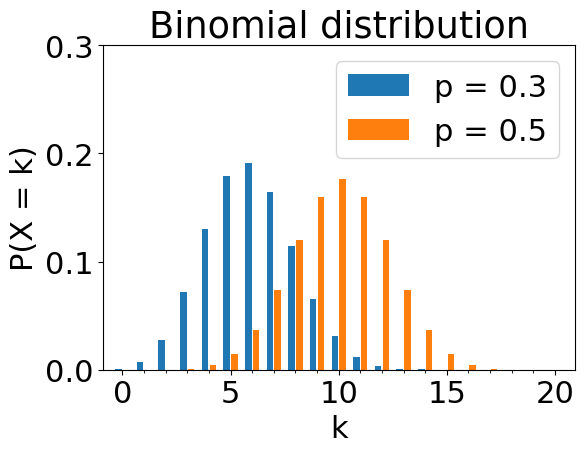

In [3]:
# prob params
n = 20
ps = [0.3,0.5]

# plot params
barWidth = 0.3

# text size
matplotlib.rcParams["font.size"] = 22

# plot them
(fig, ax) = plt.subplots (figsize=(6.5,5))

# go though ps
for (pIdx, thisP) in enumerate(ps):
    # get probs
    ks = numpy.arange (n+1)
    ys = scipy.stats.binom.pmf (ks, n, thisP)

    # plot them
    plotKs = ks + ((2*pIdx - 1) * 0.6*barWidth)
    ax.bar (plotKs, ys, width=barWidth, label=f"p = {thisP:.1f}")

ax.set_ylim ((0,0.3))
ax.set_xlim ((-0.9,n+0.9))
ax.set_ylabel ("P(X = k)")
ax.set_xlabel ("k")
ax.set_title ("Binomial distribution")
ax.legend()

# ticker
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter('{x:.0f}')
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))

# save plot
fig.tight_layout()
fig.savefig ("binomial_distribution.pdf")

#### geometric

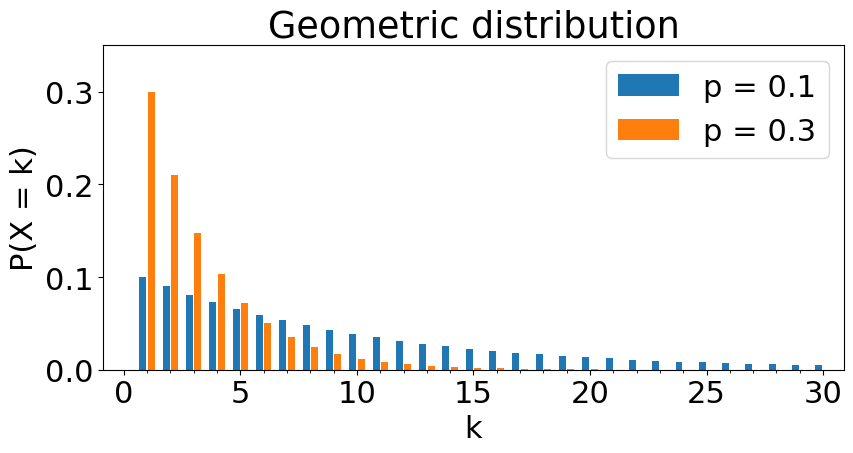

In [4]:
# prob params
maxK = 30
ps = [0.1,0.3]

# plot params
barWidth = 0.3

# text size
matplotlib.rcParams["font.size"] = 22
(fig, ax) = plt.subplots (figsize=(9,5))

# go though ps
for (pIdx, thisP) in enumerate(ps):
    # get probs
    ks = numpy.arange (maxK+1)
    ys = scipy.stats.geom.pmf (ks, thisP)

    # plot them
    plotKs = ks + ((2*pIdx - 1) * 0.6*barWidth)
    ax.bar (plotKs, ys, width=barWidth, label=f"p = {thisP:.1f}")

ax.set_ylim ((0,0.35))
ax.set_xlim ((-0.9,maxK+0.9))
ax.set_ylabel ("P(X = k)")
ax.set_xlabel ("k")
ax.set_title ("Geometric distribution")
ax.legend()

# ticker
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter('{x:.0f}')
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))

# save plot
fig.tight_layout()
fig.savefig ("geometric_distribution.pdf")

#### poisson

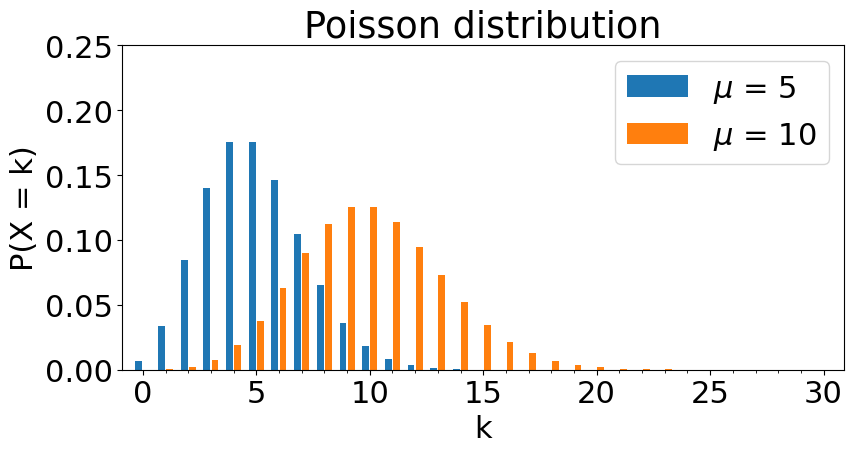

In [7]:
# prob params
maxK = 30
mus = [5,10]

# plot params
barWidth = 0.3

# text size
matplotlib.rcParams["font.size"] = 22
(fig, ax) = plt.subplots (figsize=(9,5))

# go though ps
for (muIdx, thisMu) in enumerate(mus):
    # get probs
    ks = numpy.arange (maxK+1)
    ys = scipy.stats.poisson.pmf (ks, thisMu)

    # plot them
    plotKs = ks + ((2*muIdx - 1) * 0.6*barWidth)
    ax.bar (plotKs, ys, width=barWidth, label=fr"$\mu$ = {thisMu:.0f}")

ax.set_ylim ((0,0.25))
ax.set_xlim ((-0.9,maxK+0.9))
ax.set_ylabel ("P(X = k)")
ax.set_xlabel ("k")
ax.set_title ("Poisson distribution")
ax.legend()

# ticker
ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
ax.xaxis.set_major_formatter('{x:.0f}')
ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))

# save plot
fig.tight_layout()
fig.savefig ("poisson_distribution.pdf")

#### conditional binomial

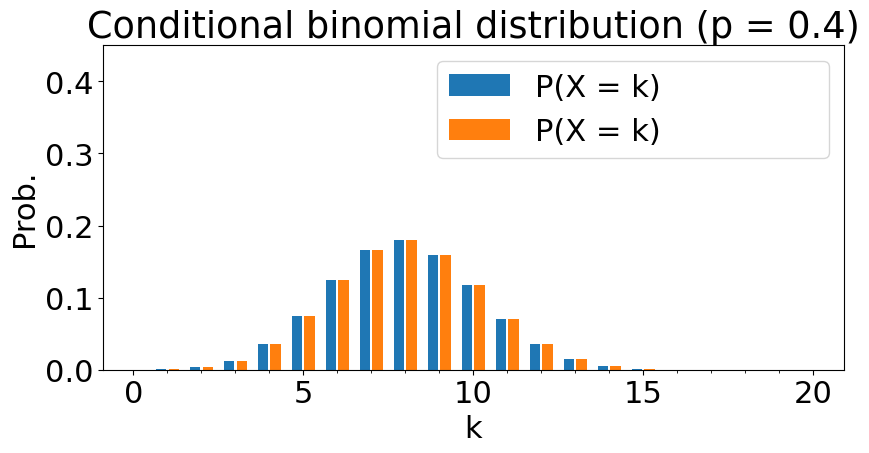

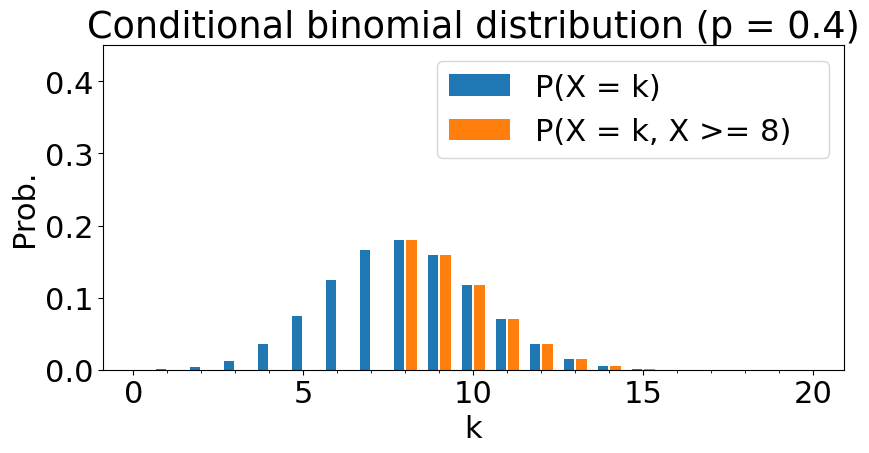

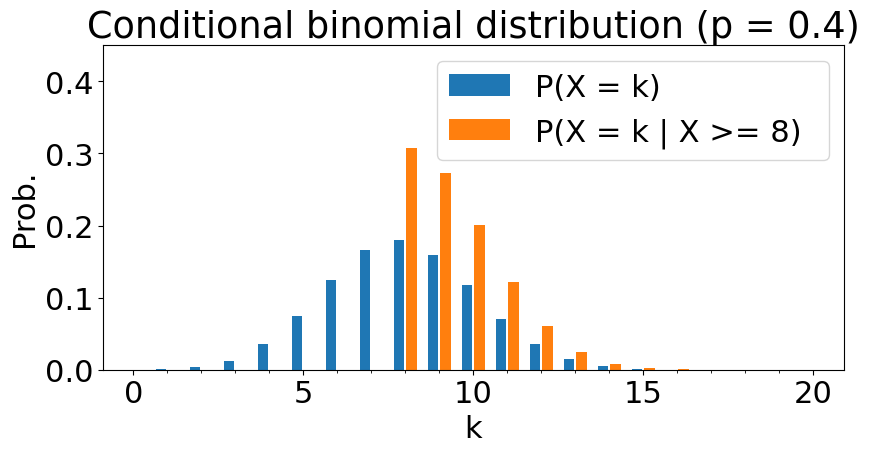

In [6]:
# prob params
n = 20
p = 0.4
minK = 8

#scenarios
scenarios = [
    'uncond',
    'restrict',
    'cond',
]

# plot params
barWidth = 0.3

for thisScenario in scenarios:
    # text size, ax and stuff
    matplotlib.rcParams["font.size"] = 22
    (fig, ax) = plt.subplots (figsize=(9,5))

    ks = numpy.arange (n+1)

    # compute/plot first probs
    pOne = scipy.stats.binom.pmf (ks, n, p)
    plotKs = ks - 0.6*barWidth
    ax.bar (plotKs, pOne, width=barWidth, label=f"P(X = k)                ")

    # compute/plot second probs
    plotKs = ks + 0.6*barWidth
    if (thisScenario == 'uncond'):
        pTwo = scipy.stats.binom.pmf (ks, n, p)
        thisLabel = f"P(X = k)"
    elif (thisScenario == 'restrict'):
        pTwo = scipy.stats.binom.pmf (ks, n, p)
        pTwo[ks < minK] = 0
        thisLabel = f"P(X = k, X >= {minK})"
    elif (thisScenario == 'cond'):
        pTwo = scipy.stats.binom.pmf (ks, n, p)
        pTwo[ks < minK] = 0
        pTwo /= pTwo.sum()
        thisLabel = f"P(X = k | X >= {minK})"
    else:
        assert (False)
    ax.bar (plotKs, pTwo, width=barWidth, label=thisLabel)
    
    ax.set_ylim ((0,0.45))
    ax.set_xlim ((-0.9,n+0.9))
    ax.set_ylabel ("Prob.")
    ax.set_xlabel ("k")
    ax.set_title (f"Conditional binomial distribution (p = {p:.1f})")
    ax.legend()

    # ticker
    ax.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_major_formatter('{x:.0f}')
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(1))

    # save plot
    fig.tight_layout()
    # fig.show()
    fig.savefig (f"conditional_binomial_{thisScenario}.pdf")